# Scikit-Learn Journal

In this notebook, I prepare a Pokemon dataset, train a linear regression model to predict `Attack`, and then compare the real values with the predicted values.

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import joblib


## Data Preparation

I load the CSV file, fill the missing values in `Type 2`, and then encode the categorical columns with `get_dummies`.

In [48]:
data = pd.read_csv("data/pokemon.csv")
df = pd.DataFrame(data)
df["Type 2"] = df["Type 2"].fillna("None")
df = pd.get_dummies(data=df, columns=["Type 1", "Type 2"])

print(f"df.shape -> {df.shape}")
df.head()

df.shape -> (800, 48)


,#,Name,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,...,Type 2_Grass,Type 2_Ground,Type 2_Ice,Type 2_None,Type 2_Normal,Type 2_Poison,Type 2_Psychic,Type 2_Rock,Type 2_Steel,Type 2_Water
0,1,Bulbasaur,318,45,49,49,65,65,45,1,...,False,False,False,False,False,True,False,False,False,False
1,2,Ivysaur,405,60,62,63,80,80,60,1,...,False,False,False,False,False,True,False,False,False,False
2,3,Venusaur,525,80,82,83,100,100,80,1,...,False,False,False,False,False,True,False,False,False,False
3,3,VenusaurMega Venusaur,625,80,100,123,122,120,80,1,...,False,False,False,False,False,True,False,False,False,False
4,4,Charmander,309,39,52,43,60,50,65,1,...,False,False,False,True,False,False,False,False,False,False


## Features And Target

I separate the input features `x` from the target variable `y`. Here, the value to predict is `Attack`.

In [49]:
feature_columns = ["HP", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
x = df[feature_columns]
y = df["Attack"]

print(f"features -> {feature_columns}")
print(f"x.shape -> {x.shape}")
print(f"y.shape -> {y.shape}")

features -> ['HP', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
x.shape -> (800, 5)
y.shape -> (800,)


## Linear Regression

I split the data into train and test sets, train a `LinearRegression` model, and then compute the `R²` score.

In [61]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=300,
)

param_grid = {
    'n_estimators': [3000],
    'max_depth': [15],
    'min_samples_split': [2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=300),
    param_grid=param_grid,
    cv= 5,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(x_train, y_train)
best_model = grid_search.best_estimator_
joblib.dump(best_model, "models/pokemon.pkl")
y_pred = best_model.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(grid_search.best_params_, grid_search.best_score_, r2)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 3000} 0.43492328012715287 0.5071366589146912


## Prediction Chart

I plot a scatter chart between the real values and the predicted values. The red line represents the ideal prediction.

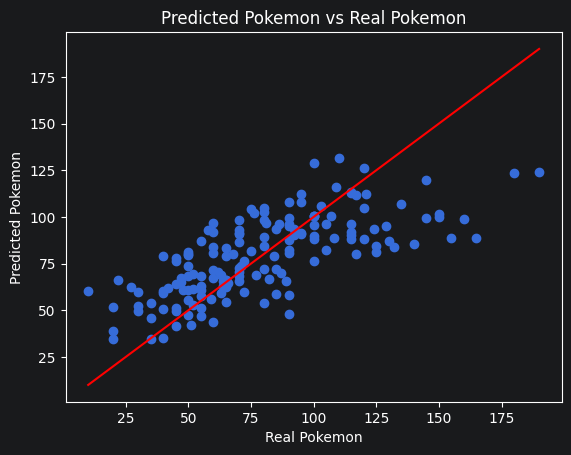

In [62]:
plt.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color="red")
plt.xlabel("Real Pokemon")
plt.ylabel("Predicted Pokemon")
plt.title("Predicted Pokemon vs Real Pokemon")
plt.show()